In [1]:
print("Customer churn project1")


Customer churn project1


# Customer Churn Prediction Using Machine Learning

### Telecom Customer Churn Analysis & Prediction

This project analyzes telecom customer data to identify factors associated with customer churn and develops machine learning models to predict customers who are at risk of leaving the company.

## Objective

To analyze customer behavior, identify key factors associated with churn, and develop a machine learning model that can help telecom companies identify customers at higher risk of churn and support targeted retention strategies.

## Business Problem

Customer churn is a major challenge for telecom companies because losing existing customers can negatively affect revenue and increase the cost of acquiring new customers.

The goal of this project is to use historical customer data to understand churn patterns and build a predictive model that can identify customers who are more likely to churn.

The insights from the analysis can help businesses design targeted customer-retention strategies.

In [107]:
# Importinh all the neccessery libraries for the project

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [108]:
import sys
print(sys.executable)

e:\linux\customer_churn_project\pjt_env\Scripts\python.exe


In [109]:
df = pd.read_csv("../data/raw/telco.csv") ## relative path not absolute
df.head()


,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


In [110]:
df.shape
# 7043 X 50

(7043, 50)

In [111]:
df.describe()
# it gives statistical overview fo data, mean, max ,median, etc


,Age,Number of Dependents,Zip Code,Latitude,Longitude,Population,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Churn Score,CLTV
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,46.509726,0.468692,93486.070567,36.197455,-119.756684,22139.603294,1.951867,32.386767,22.958954,20.515405,64.761692,2280.381264,1.962182,6.860713,749.099262,3034.379056,3.244924,58.505040,4400.295755
std,16.750352,0.962802,1856.767505,2.468929,2.154425,21152.392837,3.001199,24.542061,15.448113,20.418940,30.090047,2266.220462,7.902614,25.104978,846.660055,2865.204542,1.201657,21.170031,1183.057152
min,19.000000,0.000000,90001.000000,32.555828,-124.301372,11.000000,0.000000,1.000000,0.000000,0.000000,18.250000,18.800000,0.000000,0.000000,0.000000,21.360000,1.000000,5.000000,2003.000000
25%,32.000000,0.000000,92101.000000,33.990646,-121.788090,2344.000000,0.000000,9.000000,9.210000,3.000000,35.500000,400.150000,0.000000,0.000000,70.545000,605.610000,3.000000,40.000000,3469.000000
50%,46.000000,0.000000,93518.000000,36.205465,-119.595293,17554.000000,0.000000,29.000000,22.890000,17.000000,70.350000,1394.550000,0.000000,0.000000,401.440000,2108.640000,3.000000,61.000000,4527.000000
75%,60.000000,0.000000,95329.000000,38.161321,-117.969795,36125.000000,3.000000,55.000000,36.395000,27.000000,89.850000,3786.600000,0.000000,0.000000,1191.100000,4801.145000,4.000000,75.500000,5380.500000
max,80.000000,9.000000,96150.000000,41.962127,-114.192901,105285.000000,11.000000,72.000000,49.990000,85.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000,5.000000,96.000000,6500.000000


In [112]:
df.info()
#  it will give info about null, data type, and rangeindex

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 50 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   str    
 1   Gender                             7043 non-null   str    
 2   Age                                7043 non-null   int64  
 3   Under 30                           7043 non-null   str    
 4   Senior Citizen                     7043 non-null   str    
 5   Married                            7043 non-null   str    
 6   Dependents                         7043 non-null   str    
 7   Number of Dependents               7043 non-null   int64  
 8   Country                            7043 non-null   str    
 9   State                              7043 non-null   str    
 10  City                               7043 non-null   str    
 11  Zip Code                           7043 non-null   int64  
 12  Lat

In [113]:
# counting all nulls in each columns
df.isnull().sum()
# we got null in column: offer, internet type and Churn Category  

Customer ID                             0
Gender                                  0
Age                                     0
Under 30                                0
Senior Citizen                          0
Married                                 0
Dependents                              0
Number of Dependents                    0
Country                                 0
State                                   0
City                                    0
Zip Code                                0
Latitude                                0
Longitude                               0
Population                              0
Quarter                                 0
Referred a Friend                       0
Number of Referrals                     0
Tenure in Months                        0
Offer                                3877
Phone Service                           0
Avg Monthly Long Distance Charges       0
Multiple Lines                          0
Internet Service                  

In [114]:
# check duplicates
df.duplicated().sum()
#  no duplicates

np.int64(0)

In [115]:
# chexk unique values in each column  via( *NUNIQUE*)
# if gender column have more than 2 unique values it means spelling mistake

df.nunique()

Customer ID                          7043
Gender                                  2
Age                                    62
Under 30                                2
Senior Citizen                          2
Married                                 2
Dependents                              2
Number of Dependents                   10
Country                                 1
State                                   1
City                                 1106
Zip Code                             1626
Latitude                             1626
Longitude                            1625
Population                           1569
Quarter                                 1
Referred a Friend                       2
Number of Referrals                    12
Tenure in Months                       72
Offer                                   5
Phone Service                           2
Avg Monthly Long Distance Charges    3584
Multiple Lines                          2
Internet Service                  

In [116]:
# inspect each categorical column e.g gender
df["Gender"].unique()

<StringArray>
['Male', 'Female']
Length: 2, dtype: str

In [117]:
# check the targated  variable(churn)
df["Churn Label"].value_counts()

# output
# Churn Label
# No     5174
# Yes    1869



Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

In [118]:
df["Churn Label"].value_counts(normalize=True) * 100
# it will give in percentage proportion

Churn Label
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

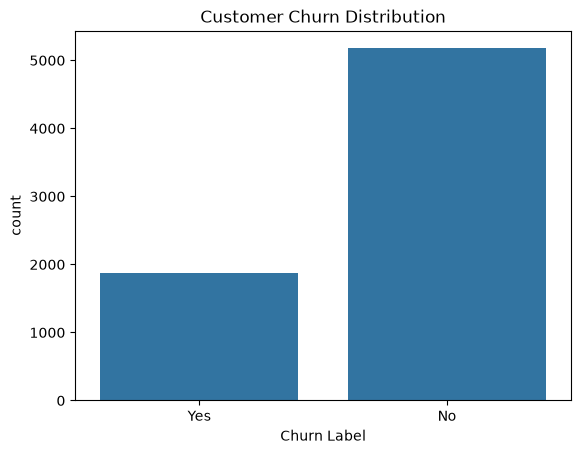

In [119]:
sns.countplot(x="Churn Label", data=df)

plt.title("Customer Churn Distribution")

plt.show()

In [120]:
# Step 19: Separate Numerical and Categorical columns

print("Separated Numerical Data only:")
numData = df.select_dtypes(include=["int64","float64"]).columns

print("Here are all numerical Columns:")
print(numData)

print("Separated String Data only:")

strdata = df.select_dtypes(include= ["object"]).columns
print("Here are all the string columns:")
print(strdata)

Separated Numerical Data only:
Here are all numerical Columns:
Index(['Age', 'Number of Dependents', 'Zip Code', 'Latitude', 'Longitude',
       'Population', 'Number of Referrals', 'Tenure in Months',
       'Avg Monthly Long Distance Charges', 'Avg Monthly GB Download',
       'Monthly Charge', 'Total Charges', 'Total Refunds',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Revenue', 'Satisfaction Score', 'Churn Score', 'CLTV'],
      dtype='str')
Separated String Data only:
Here are all the string columns:
Index(['Customer ID', 'Gender', 'Under 30', 'Senior Citizen', 'Married',
       'Dependents', 'Country', 'State', 'City', 'Quarter',
       'Referred a Friend', 'Offer', 'Phone Service', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Online Security', 'Online Backup',
       'Device Protection Plan', 'Premium Tech Support', 'Streaming TV',
       'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract',
       'Paperless 

C:\Users\jk714\AppData\Local\Temp\ipykernel_10616\3466323211.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  strdata = df.select_dtypes(include= ["object"]).columns


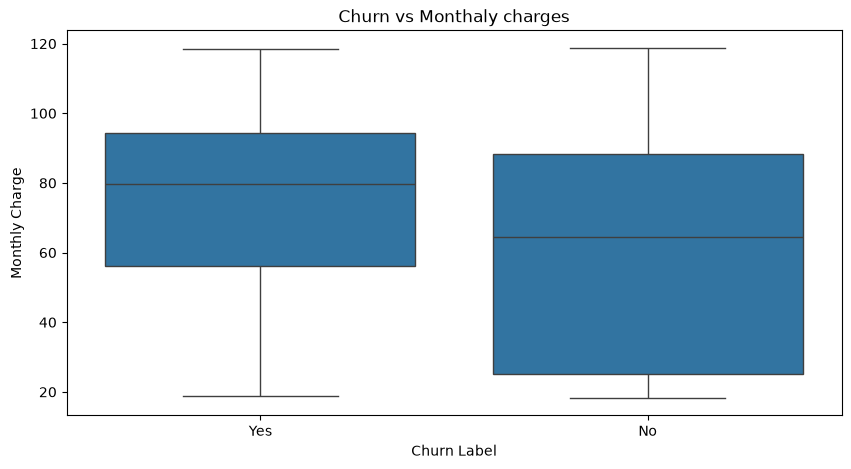

In [121]:
plt.figure(figsize=(10,5)) # chart ka size 
sns.boxplot(x= "Churn Label", y = "Monthly Charge", data = df)
plt.title("Churn vs Monthaly charges")
plt.show()


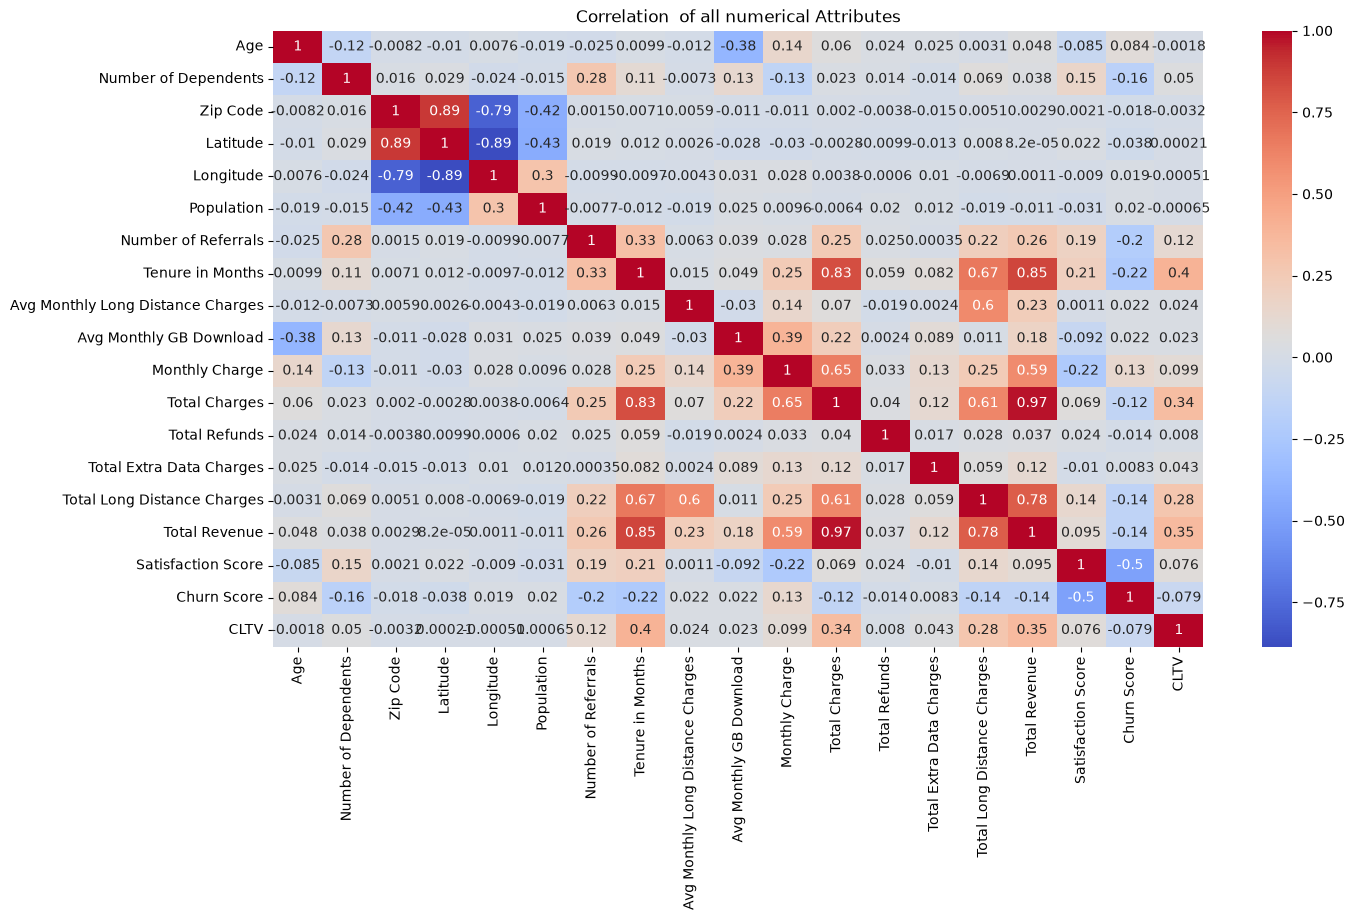

In [122]:
plt.figure(figsize=(15,8))
sns.heatmap(df[numData].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation  of all numerical Attributes")
plt.show()

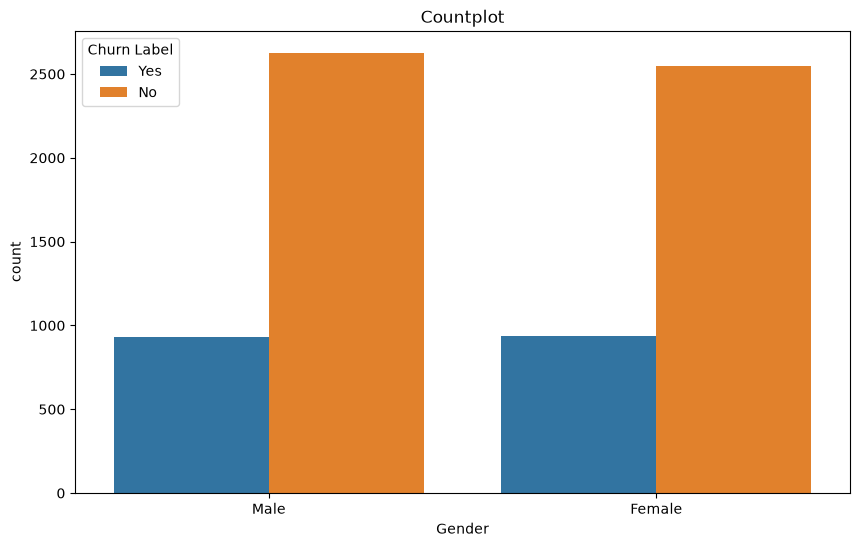

In [123]:

# Now do some EDA for Categorical attributes :

#GENDER 
plt.figure(figsize=(10,6))

# countplot creates a bar chart that counts the number of occurrences of each category.

sns.countplot(x = "Gender", hue= "Churn Label", data = df)
#if we took "y" instead "hue" it wont work
# "x/y" is for what we are counting
# "hue" is for how we want to split the results
#if we took "m" instead "y" it wont work
plt.title("Countplot")
plt.show()

In [124]:
top_cities = df["City"].value_counts().head(10).index
# ".index" cities k names index karega agr nhi lagate to result show nhi hoga
top_cities

Index(['Los Angeles', 'San Diego', 'San Jose', 'Sacramento', 'San Francisco',
       'Fresno', 'Long Beach', 'Oakland', 'Escondido', 'Stockton'],
      dtype='str', name='City')

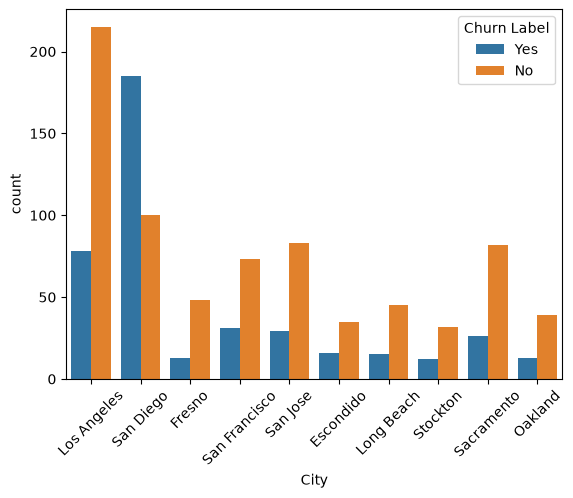

In [125]:
# Option 1 (Recommended): Plot only the top cities
sns.countplot(x = "City",
              hue= "Churn Label",
              data = df[df["City"].isin(top_cities)])
plt.xticks( rotation = 45) # labels ko thoda sa tilt krta h
plt.show()

# NOTE: SNS is basically built on plt that is why we can call it via plt.show()
# df["City"].isin(top_cities) = will give only boolean results (true n false)
# df[df["City"].isin(top_cities)] = will give full values

In [126]:
# Option 2: Use a frequency table instead

df.groupby("City")["Churn Label"].value_counts()

# 

City          Churn Label
Acampo        Yes            3
              No             1
Acton         No             4
Adelanto      No             4
              Yes            1
                            ..
Yucaipa       No             3
              Yes            1
Yucca Valley  No             5
Zenia         No             3
              Yes            1
Name: count, Length: 1875, dtype: int64

In [127]:
# Data processing cleaning, preparing, finding null and duplicates, etc.

df.isnull().sum()
# there are null values required to tackle 



Customer ID                             0
Gender                                  0
Age                                     0
Under 30                                0
Senior Citizen                          0
Married                                 0
Dependents                              0
Number of Dependents                    0
Country                                 0
State                                   0
City                                    0
Zip Code                                0
Latitude                                0
Longitude                               0
Population                              0
Quarter                                 0
Referred a Friend                       0
Number of Referrals                     0
Tenure in Months                        0
Offer                                3877
Phone Service                           0
Avg Monthly Long Distance Charges       0
Multiple Lines                          0
Internet Service                  

In [128]:
df.duplicated().sum()
# no duplicates no need to handle it 


np.int64(0)

In [129]:
# before handling the null values we need to remove all the
# unnecessary columns e.g cutomerid, 
clm = df.columns.tolist()
clm

# create a copy of data set for further operations 
df_copy = df.copy()

# now drop all unnecessary coloumns from df_copy dataset
df_copy = df_copy.drop(columns =["Customer ID", 
                        "Customer Status",
                        "Churn Score",
                        "Churn Category",
                        "Churn Reason",
                        "Country",
                        "State"

])

In [130]:

cl = df_copy.columns.tolist()
cl

['Gender',
 'Age',
 'Under 30',
 'Senior Citizen',
 'Married',
 'Dependents',
 'Number of Dependents',
 'City',
 'Zip Code',
 'Latitude',
 'Longitude',
 'Population',
 'Quarter',
 'Referred a Friend',
 'Number of Referrals',
 'Tenure in Months',
 'Offer',
 'Phone Service',
 'Avg Monthly Long Distance Charges',
 'Multiple Lines',
 'Internet Service',
 'Internet Type',
 'Avg Monthly GB Download',
 'Online Security',
 'Online Backup',
 'Device Protection Plan',
 'Premium Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Streaming Music',
 'Unlimited Data',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Monthly Charge',
 'Total Charges',
 'Total Refunds',
 'Total Extra Data Charges',
 'Total Long Distance Charges',
 'Total Revenue',
 'Satisfaction Score',
 'Churn Label',
 'CLTV']

In [131]:
# after removing unnecessary
# check null values

df_copy.isnull().sum()
df.isnull().sum()
# churn category and churn reason has been deleted
# "offer"  and "Internet Type" both columns
#  are left with null values

Customer ID                             0
Gender                                  0
Age                                     0
Under 30                                0
Senior Citizen                          0
Married                                 0
Dependents                              0
Number of Dependents                    0
Country                                 0
State                                   0
City                                    0
Zip Code                                0
Latitude                                0
Longitude                               0
Population                              0
Quarter                                 0
Referred a Friend                       0
Number of Referrals                     0
Tenure in Months                        0
Offer                                3877
Phone Service                           0
Avg Monthly Long Distance Charges       0
Multiple Lines                          0
Internet Service                  

In [132]:
# Now checking why "Offer" and "internet Type" columns have null values

# for "Offer"

df_copy["Offer"].value_counts(dropna= False)
# dropna means show me all values even they are null
# NaN are 3877 and rest are 3166 with different types of offers

Offer
NaN        3877
Offer B     824
Offer E     805
Offer D     602
Offer A     520
Offer C     415
Name: count, dtype: int64

In [133]:
# for "Internet Type"
df_copy["Internet Type"].value_counts(dropna= False)

# NaN = 1526 and rest are  5517

Internet Type
Fiber Optic    3035
DSL            1652
NaN            1526
Cable           830
Name: count, dtype: int64

In [134]:
# Cross check internet type column with internet service even they have it or not
# firstly check the unique values in it 
df_copy["Internet Service"].value_counts()
# so those who does not have service are == 1526

# hence NaN = No Service 

Internet Service
Yes    5517
No     1526
Name: count, dtype: int64

In [135]:
# fill all the null values in "internet type"
#  with "no internet" instead of putting median or mode value

df_copy["Internet Type"] = df_copy["Internet Type"].fillna("No internet")
df_copy["Internet Type"].value_counts(dropna = False)

# No Null or NaN values 

# now do same for "Offer" Column

Internet Type
Fiber Optic    3035
DSL            1652
No internet    1526
Cable           830
Name: count, dtype: int64

In [136]:
df_copy["Offer"] = df_copy["Offer"].fillna("No offer")

df_copy["Offer"].value_counts(dropna = False)

#  all set no null values in any column


Offer
No offer    3877
Offer B      824
Offer E      805
Offer D      602
Offer A      520
Offer C      415
Name: count, dtype: int64

In [137]:
# Verifying  null values
df_copy.isnull().sum()
# Verified no null values 

Gender                               0
Age                                  0
Under 30                             0
Senior Citizen                       0
Married                              0
Dependents                           0
Number of Dependents                 0
City                                 0
Zip Code                             0
Latitude                             0
Longitude                            0
Population                           0
Quarter                              0
Referred a Friend                    0
Number of Referrals                  0
Tenure in Months                     0
Offer                                0
Phone Service                        0
Avg Monthly Long Distance Charges    0
Multiple Lines                       0
Internet Service                     0
Internet Type                        0
Avg Monthly GB Download              0
Online Security                      0
Online Backup                        0
Device Protection Plan   

In [138]:
# Nowwww Encoding all possible categorical values in Numerical format
# firstly, identified the categorical Columns

# catgry = df_copy.select_dtypes(include = "object") # This is giving full data of all columns

catgry = df_copy.select_dtypes(include = "object").columns # it will give only names of columns
catgry

C:\Users\jk714\AppData\Local\Temp\ipykernel_10616\1018179403.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  catgry = df_copy.select_dtypes(include = "object").columns # it will give only names of columns


Index(['Gender', 'Under 30', 'Senior Citizen', 'Married', 'Dependents', 'City',
       'Quarter', 'Referred a Friend', 'Offer', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Internet Type',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method', 'Churn Label'],
      dtype='str')

In [139]:
# now check how many categorical columns have only 
# two categories or one, like yes or no, male n female

df_copy.nunique()
# drop quarter column bcz it has only 1 value (Q3)
df_copy = df_copy.drop(columns ="Quarter")

# output :
# Here is your data rearranged by the unique value count (quantity), starting with 2, then 3, and finally 1 at the bottom.

# | Feature | Unique Values |
# | --- | --- |
# | Gender | 2 |
# | Under 30 | 2 |
# | Senior Citizen | 2 |
# | Married | 2 |
# | Dependents | 2 |
# | Referred a Friend | 2 |
# | Phone Service | 2 |
# | Multiple Lines | 2 |
# | Internet Service | 2 |
# | Online Security | 2 |
# | Online Backup | 2 |
# | Device Protection Plan | 2 |
# | Premium Tech Support | 2 |
# | Streaming TV | 2 |
# | Streaming Movies | 2 |
# | Streaming Music | 2 |
# | Unlimited Data | 2 |
# | Paperless Billing | 2 |
# | Churn Label | 2 |
# | Internet Type | 3 |
# | Contract | 3 |
# | Payment Method | 3 |



In [140]:
# Now Encoding  all binary values i.g, male female and Yes No only!

# Lable Encode Binary columns, 
# Creat a list all of them to automate it

bin_clms = ["Gender",
    "Under 30",
    "Senior Citizen",
    "Married",
    "Dependents",
    "Referred a Friend",
    "Phone Service",
    "Multiple Lines",
    "Internet Service",
    "Online Security",
    "Online Backup",
    "Device Protection Plan",
    "Premium Tech Support",
    "Streaming TV",
    "Streaming Movies",
    "Streaming Music",
    "Unlimited Data",
    "Paperless Billing",
    "Churn Label"]

In [141]:
# Now encode it with help of LabelEncoder and sk-learn

from sklearn.preprocessing import LabelEncoder
# This imports the LabelEncoder class from Scikit-Learn

le = LabelEncoder()
# This creates a LabelEncoder object

for col in bin_clms:
   df_copy[col] = le.fit_transform(df_copy[col])
#  fit()
# Looks at the unique values
# transform()
# It converts them into numbers.
#  df_copy[col]  (here we are saving results)




In [142]:
# verifying the changes
df_copy[bin_clms].head()

,Gender,Under 30,Senior Citizen,Married,Dependents,Referred a Friend,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection Plan,Premium Tech Support,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data,Paperless Billing,Churn Label
0,1,0,1,0,0,0,0,0,1,0,0,1,0,0,1,0,0,1,1
1,0,0,1,1,1,1,1,1,1,0,1,0,0,0,0,0,1,1,1
2,1,0,1,0,1,0,1,1,1,0,0,0,0,1,1,1,1,1,1
3,0,0,1,1,1,1,1,0,1,0,1,1,0,1,1,0,1,1,1
4,0,0,1,1,1,1,1,1,1,0,0,0,0,0,0,0,1,1,1


In [143]:
# now handle those categorical columns those have 3 values 
# create a list of them
df_copy.nunique()

# mlti_clms = ["Internet Type", "Contract", "Payment Method", "etc"]


Gender                                  2
Age                                    62
Under 30                                2
Senior Citizen                          2
Married                                 2
Dependents                              2
Number of Dependents                   10
City                                 1106
Zip Code                             1626
Latitude                             1626
Longitude                            1625
Population                           1569
Referred a Friend                       2
Number of Referrals                    12
Tenure in Months                       72
Offer                                   6
Phone Service                           2
Avg Monthly Long Distance Charges    3584
Multiple Lines                          2
Internet Service                        2
Internet Type                           4
Avg Monthly GB Download                50
Online Security                         2
Online Backup                     

In [144]:
print(df.columns.tolist())

['Customer ID', 'Gender', 'Age', 'Under 30', 'Senior Citizen', 'Married', 'Dependents', 'Number of Dependents', 'Country', 'State', 'City', 'Zip Code', 'Latitude', 'Longitude', 'Population', 'Quarter', 'Referred a Friend', 'Number of Referrals', 'Tenure in Months', 'Offer', 'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines', 'Internet Service', 'Internet Type', 'Avg Monthly GB Download', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Revenue', 'Satisfaction Score', 'Customer Status', 'Churn Label', 'Churn Score', 'CLTV', 'Churn Category', 'Churn Reason']


In [145]:
# We are dropping high cardinality and "data-leakage" columns that are irrelevent to our model buuilding
drop_cols = [
    "Customer ID",
    "City",
    "Zip Code",
    "Latitude",
    "Longitude",
    "Quarter", "Population",
    "Customer Status",
"Churn Score",
"Churn Category",
"Churn Reason",
"Country",
"State", "Satisfaction Score"
 
]

df_copy = df.drop(columns=drop_cols).copy()

# Why?
# Column	  Decision	  Reason
# Customer ID  Drop	 Just an identifier
# City	       Drop	 1,106 categories → huge one-hot encoding
# Zip Code	   Drop	 1,626 categories
# Latitude	   Drop	 Geographic location; unnecessary for our first model
# Longitude	   Drop	 Same
# Quarter	   Drop	 Doesn't provide useful customer-level information
# Population   Drop 
# state/ country

# LEAKAGE COLUMNS

# These columns contain information that is essentially available because of the customer's churn outcome.

# For example:

# Churn Reason → tells us why they churned
# Churn Category → tells us the churn category
# Customer Status → tells us whether they're active/churned
# Churn Score → is itself a score related to churn

# If we leave them in X, our model can "cheat" and produce an unrealistically high accuracy.

In [146]:
print(df_copy.shape)
print(df_copy.columns.tolist())

(7043, 36)
['Gender', 'Age', 'Under 30', 'Senior Citizen', 'Married', 'Dependents', 'Number of Dependents', 'Referred a Friend', 'Number of Referrals', 'Tenure in Months', 'Offer', 'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines', 'Internet Service', 'Internet Type', 'Avg Monthly GB Download', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Revenue', 'Churn Label', 'CLTV']


In [147]:
print(df.shape)

(7043, 50)


In [148]:
# Separate X and y
xx = df_copy.drop("Churn Label", axis=1)
# "x" input hota hia isliye x se remove kr diya or baki 
yy = df_copy["Churn Label"]
# "y" output deta hai isliye y axis pr rakha hai
#  because "Churn Label" target variable hai!

In [149]:
print("xx:", xx.shape)
print("yy:", yy.shape)

xx: (7043, 35)
yy: (7043,)


In [150]:
print(yy.unique())
print(yy.value_counts())

<StringArray>
['Yes', 'No']
Length: 2, dtype: str
Churn Label
No     5174
Yes    1869
Name: count, dtype: int64


In [151]:
# Convert Yes/No to 0/1
yy = yy.map({"No": 0, "Yes": 1})

# NOTE: Don't use LabelEncoder for y here
# WE could, but mapping explicitly is clearer:


In [152]:
print(yy.value_counts())

Churn Label
0    5174
1    1869
Name: count, dtype: int64


In [153]:
# Find categorical columns
# catgry = df_copy.select_dtypes(include = "object").columns # it will give only names of columns
# better than this

# catgry = df_copy.select_dtypes(include=["object", "str"]).columns

# However, there's an even better approach for your current pipeline.
# coz we have split it in that way 

# X = df_copy.drop("Churn Label", axis=1)
# y = df_copy["Churn Label"]

# so we can do this 

catgry = xx.select_dtypes(include=["object", "str"]).columns

print(catgry)




Index(['Gender', 'Under 30', 'Senior Citizen', 'Married', 'Dependents',
       'Referred a Friend', 'Offer', 'Phone Service', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Online Security', 'Online Backup',
       'Device Protection Plan', 'Premium Tech Support', 'Streaming TV',
       'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract',
       'Paperless Billing', 'Payment Method'],
      dtype='str')


In [154]:
# Then encode them:

xx = pd.get_dummies(
    xx,
    columns=catgry,
    drop_first=True
)

# get_dummies() converts categorical/text values into numerical columns 




In [155]:
# checking all str values are converted to numerical values or not

print(xx.shape)
print(xx.select_dtypes(include=["object", "str"]).columns)

(7043, 41)
Index([], dtype='str')


In [156]:
# Check Missing Values
print("Missing values in xx:", xx.isnull().sum().sum())
print("Missing values in yy:", yy.isnull().sum())

Missing values in xx: 0
Missing values in yy: 0


In [157]:
# Now train and test phase

from sklearn.model_selection import train_test_split

xx_train, xx_test, yy_train, yy_test = train_test_split(
    xx,
    yy,
    test_size=0.20,
    random_state=32,
    stratify=yy
)

# A seed is a starting value given to a random-number generator. here seed is = 32


In [158]:
# Now verify it

print("Xx_train:", xx_train.shape)
print("Xx_test :", xx_test.shape)
print("yy_train:", yy_train.shape)
print("yy_test :", yy_test.shape)

Xx_train: (5634, 41)
Xx_test : (1409, 41)
yy_train: (5634,)
yy_test : (1409,)


In [159]:
# Feature Scaling

# Why?
# Your features have very different ranges:

# Without scaling, some algorithms such as Logistic Regression
#  can be affected by these different scales.

# We will use StandardScaler.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

xx_train = scaler.fit_transform(xx_train)
xx_test = scaler.transform(xx_test)


In [160]:
# Training data:

xx_train = scaler.fit_transform(xx_train)

# fit → learns the mean and standard deviation from the training data.
# transform → uses those values to scale the training data.






In [161]:
# Test data:

xx_test = scaler.transform(xx_test)

In [162]:
# We only transform the test data.

# We don't do:

# scaler.fit_transform(X_test)

# because that would allow information from the test set to influence our preprocessing. That's a form of data leakage.

In [163]:
# Verify it
print(xx_train.shape)
print(xx_test.shape)

(5634, 41)
(1409, 41)


In [164]:
# Train First Model: Logistic Regression

from sklearn.linear_model import LogisticRegression


In [165]:
# creating model

LR_model = LogisticRegression(random_state=32)

# model is a variable to store "LR " model

In [166]:
# Train the model

LR_model.fit(xx_train, yy_train)

# "Model, learn the relationship between these customer features "
# "(X_train) and their actual churn outcomes (y_train)."

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",32
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [167]:
# Make predictions

y_pred = LR_model.predict(xx_test)

In [168]:
# Check the predictions
print(y_pred[:20])

[0 0 0 0 1 0 0 1 1 1 0 0 0 0 0 1 1 0 0 0]


In [169]:
# Check class order:

LR_model.classes_

array([0, 1])

In [170]:
# Check the model's probability instead of direct yes or no(0,1) answer

y_prob = LR_model.predict_proba(xx_test)[:, 1]
#translation:

# "Calculate probabilities for both classes for every test customer,
# then take the probability corresponding to class 1 (Churn)."

y_prob




array([0.25685911, 0.00767182, 0.16189141, ..., 0.58586494, 0.04890543,
       0.09628027], shape=(1409,))

In [171]:


# for better visualization probability result

import numpy as np
print(np.round(y_prob, 4))


y_prob




[0.2569 0.0077 0.1619 ... 0.5859 0.0489 0.0963]


array([0.25685911, 0.00767182, 0.16189141, ..., 0.58586494, 0.04890543,
       0.09628027], shape=(1409,))

In [172]:
x_prob = np.round(y_prob * 100, 2)

x_prob

array([25.69,  0.77, 16.19, ..., 58.59,  4.89,  9.63], shape=(1409,))

In [173]:
# Check the predictions
print(y_pred)

[0 0 0 ... 1 0 0]


In [174]:
# And check how many predictions of each class


np.unique(y_pred, return_counts=True)

(array([0, 1]), array([1047,  362]))

In [175]:
# Then calculate accuracy:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(yy_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8353442157558553


In [176]:
# we'll create the confusion matrix

y_pred = (y_prob >= 0.5).astype(int)

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(yy_test, y_pred)) #96% accuracy after removing "Satisfaction score" it is 83.5%
print("\nConfusion Matrix:")
print(confusion_matrix(yy_test, y_pred))
print("\nClassification Report:")
print(classification_report(yy_test, y_pred))


Accuracy: 0.8353442157558553

Confusion Matrix:
[[925 110]
 [122 252]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.89      0.89      1035
           1       0.70      0.67      0.68       374

    accuracy                           0.84      1409
   macro avg       0.79      0.78      0.79      1409
weighted avg       0.83      0.84      0.83      1409



In [177]:
# Calculate AUC
# AUC tells us how well the model separates churners from non-churners

from sklearn.metrics import roc_auc_score

auc = roc_auc_score(yy_test, y_prob)

print("ROC-AUC:", auc)

ROC-AUC: 0.9001653362267173


<Figure size 800x500 with 0 Axes>

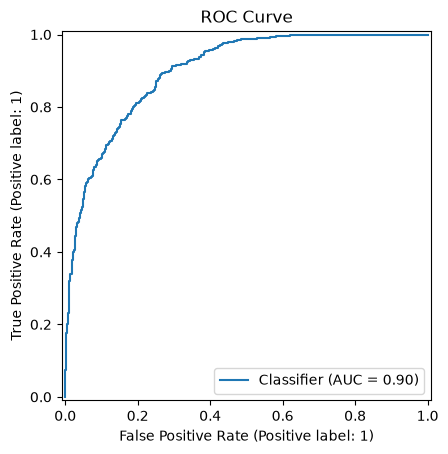

In [178]:
# Plot the ROC Curve

from sklearn.metrics import RocCurveDisplay
plt.figure(figsize =(8,5) )
RocCurveDisplay.from_predictions(yy_test, y_prob)

plt.title("ROC Curve")
plt.show()


# ROC-AUC evaluates the model across different probability thresholds, rather than only the default 0.5 threshold.
# That's why it's useful alongside accuracy, precision, recall, and F1

In [179]:
# NOTE : Your ROC curve is also very close to the top-left corner, which is exactly what we want.

# What this means
# Your Logistic Regression model is doing an excellent job at ranking churners above non-churners.

# In simple terms:
# If we randomly select one customer who churned and one who didn't, 
# the model will very often assign the churned customer a higher churn probability.

In [180]:
#NOTE: Ab baat ye hai ki jo AUC hai bo jyada achha hogya hai jiska mtl "FEATURE LEAKAGE" possible ho skta hai
# Now we are just ensuring there should not be any feature leakage that can support prediction result e.g "Satisfaction" feature
# Satisfaction Score
# CLTV
# Total Revenue
# Total Charges ::::: all these four can casue leakage

# For example:
#If we're predicting whether a customer will churn next month, can we actually know their future,
#Total Revenue or their current Satisfaction Score at prediction time?


In [181]:
# Next: Feature Importance
# Let's see what Logistic Regression has learned

coef = pd.DataFrame({
    "Feature": xx.columns,
    "Coefficient": LR_model.coef_[0]
})

# X.columns ==  we created "X" here : X = df_copy.drop("Churn Label", axis=1)
#If we write: X.columns Pandas gives us the column names:

# Where did model.coef_ come from?
#Earlier, we created the model:,, model = LogisticRegression(random_state=42)
# THEN  we trained it, During training, Logistic Regression learned a coefficient for every feature.

# For example, imagine we only had three feature
# Age              → -0.25
# Tenure           → -1.10
# Monthly Charge   → +0.75 ::==>>> These numbers are called coefficients
# Scikit-learn stores those learned coefficients inside the model as:
# model.coef_  :: The underscore _ is important

# We want to put them side by side.
# For example:
# X.columns           model.coef_
# Feature             Coefficient
# Age                 -0.25
# Tenure              -1.10
# Monthly Charge       0.75

coef["Absolute_Coefficient"] = coef["Coefficient"].abs()
# This creates another column.
# .abs() means absolute value: 0.1, -1.2 , 2.1 ==> 0.1, 1.2, 2.1
# Because we want to know the strength of the coefficient regardless of its direction.

coef = coef.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)
# Then sorting
# Sort the table according to Absolute_Coefficient, from largest to smallest.

# So we're basically saying::=> "Show me which feature has which coefficient."
print(coef.head(15))

                      Feature  Coefficient  Absolute_Coefficient
6              Monthly Charge     1.848347              1.848347
2         Number of Referrals    -1.782119              1.782119
37          Contract_Two Year    -1.181260              1.181260
3            Tenure in Months    -0.931712              0.931712
17             Dependents_Yes    -0.748614              0.748614
18      Referred a Friend_Yes     0.730783              0.730783
36          Contract_One Year    -0.568409              0.568409
27  Internet Type_Fiber Optic    -0.550180              0.550180
23          Phone Service_Yes    -0.472504              0.472504
33       Streaming Movies_Yes    -0.387703              0.387703
25       Internet Service_Yes    -0.303574              0.303574
31   Premium Tech Support_Yes    -0.288197              0.288197
28        Online Security_Yes    -0.280059              0.280059
34        Streaming Music_Yes     0.257214              0.257214
15         Senior Citizen

In [182]:
# Our important findings

# 1. Satisfaction Score → -6.73 
# This is by far the strongest coefficient.
# Business interpretation: Improving customer satisfaction may be important for retention.
# However, remember that a coefficient does not prove causation.

# 2. Number of Referrals → -2.03
# Higher referrals are associated with lower churn.
# Customers who actively refer others may be more engaged and loyal.

# Online Security → -1.36
# This could indicate that customers using additional services are more engaged with the company.

# 4. Monthly Charge → +0.95
# Higher monthly charges are associated with higher churn probability
# This is a useful business finding.

# 5. Dependents → -0.87
# Customers with dependents are associated with lower churn.

# 6. Referred a Friend → +0.84
# The coefficient is positive, meaning the encoded category Referred a Friend_Yes 
# is associated with higher predicted churn after accounting for the other features.

# Don't immediately conclude::=> "Referring friends causes churn."
# This is exactly why we need to understand the model and the data together.



In [183]:
# One thing we should investigate

# Satisfaction Score = -6.73 is extremely large compared with the other coefficients.

# Combined with our earlier 0.9938 ROC-AUC, this makes me want
# to investigate whether Satisfaction Score is available before churn occurs.

# If the score was calculated after a customer became
#  dissatisfied/churned, it could be target leakage.

# So before we build our next model, we should check the business meaning and timing of our features.

# Next step::
# We'll investigate our features for data leakage, then move to the Decision Tree model.
#This is important because there's no point comparing models if our current dataset 
#contains information that wouldn't actually be available when making a real churn prediction.


In [184]:
# Step 9 — Check for Data Leakage
# what is data leakage:
# Data leakage happens when our model gets information that would not 
# actually be available at the time we want to make the prediction.
# e.g Suppose we want to predict whether a customer will churn next month.

# if we give the model::=> Churn Reason = "Price too high"
# that's cheating—the customer has essentially already churned.
# That's why we removed: Cutomer Status, churn score, Churn Category, churn Reason

# What about our remaining features?::==> Satisfaction Score, CLTV, Total score, Total charge, etc..
# These aren't automatically leakage. We need to think about when they are measured.

# e.g::=> Satisfaction Score

# If it's a survey score collected before churn prediction → potentially valid.
# If it's calculated after the customer has churned →  leakage.




In [185]:
# Step 10 — Check Our Target Distribution

# Before building another model, let's confirm the classes:

print(yy.value_counts()) 
print(yy.value_counts(normalize=True) * 100) #And percentages:

# We should see approximately:
# 0 → 73.5%
# 1 → 26.5%
# This reminds us that accuracy alone isn't enough.


Churn Label
0    5174
1    1869
Name: count, dtype: int64
Churn Label
0    73.463013
1    26.536987
Name: proportion, dtype: float64


In [186]:
# Step 11 — Decision Tree

# Now we're ready for our second model.

from sklearn.tree import DecisionTreeClassifier

#create model:
dt_model = DecisionTreeClassifier(
    random_state=42
)

# Train it:
dt_model.fit(xx_train, yy_train)

#this means:
# Our Decision Tree learns patterns between the 42 input
#features and churn from the training data.


,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [187]:
# Make predictions
dt_pred = dt_model.predict(xx_test)


In [188]:
# Evaluate it

from sklearn.metrics import accuracy_score, classification_report

print("Decision Tree Accuracy:",
      accuracy_score(yy_test, dt_pred))

print("\nClassification Report:")
print(classification_report(yy_test, dt_pred))

# Don't worry about scaling for the Decision Tree.
# We already have: x_train & x_test

# in scaled form from our Logistic Regression pipeline:
# A Decision Tree doesn't require feature scaling, but using the scaled data 
#won't generally prevent it from working. For a clean production comparison, though,
# we'd normally maintain separate preprocessing pipelines because scaling is unnecessary for trees.

Decision Tree Accuracy: 0.7799858055358411

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.83      0.85      1035
           1       0.58      0.64      0.61       374

    accuracy                           0.78      1409
   macro avg       0.72      0.73      0.73      1409
weighted avg       0.79      0.78      0.78      1409



In [189]:
# What does this tell us?

# Our Logistic Regression had:
# Accuracy → 96.17%
# Churn Recall → 90%
# Churn F1 → 93%
# ROC-AUC → 99.38%

# Decision Tree:
# Accuracy → 95.03%
# Churn Recall → 92%
# Churn F1 → 91%

# NOTE: Logistic Regression is currently the better overall model, 
# while the Decision Tree has slightly better churn recall.

# Why might recall matter
# recall answers: Of all the customers who actually


# But there's another important thing
# WE used: dt_model = DecisionTreeClassifier(random_state=42)
# with no restrictions on the tree.
# That means the tree is allowed to grow quite freely, which can lead to overfitting.


In [190]:
# In the next step, we'll learn how to control a Decision Tree using parameters such as:

# max_depth
# min_samples_split
# min_samples_leaf  ::=>buttt we will do it later this tunning


In [191]:
# let's build our third model:
# Step 12 — Random Forest

# Random Forest is basically:
# Many Decision Trees working together and combining their predictions.
# Instead of relying on one tree, we create many trees and let them vote.

# import essentials 
from sklearn.ensemble import RandomForestClassifier

# creating model:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# n_estimators=100 → build 100 decision trees
# random_state=42 → make our results reproducible



In [192]:
# train:
rf_model.fit(xx_train, yy_train)



,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [193]:
# predict
rf_pred = rf_model.predict(xx_test)

In [194]:
# evaluate:

from sklearn.metrics import accuracy_score, classification_report

print("Random Forest Accuracy:",
      accuracy_score(yy_test, rf_pred))

print("\nClassification Report:")
print(classification_report(yy_test, rf_pred))

# NOTE: Random Forest doesn't require feature scaling. Our Logistic Regressio needed 
#scaling, but tree-based algorithms don't depend on feature magnitude in the same way.

# For now, we'll continue with our existing X_train/X_test so the workflow
# stays simple. Later, when we organize this as a production-quality pipeline,
# we'll separate the preprocessing for scale-sensitive and tree-based models.



Random Forest Accuracy: 0.8332150461320085

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.91      0.89      1035
           1       0.72      0.61      0.66       374

    accuracy                           0.83      1409
   macro avg       0.79      0.76      0.77      1409
weighted avg       0.83      0.83      0.83      1409



In [195]:
# Our results so far for all three model
# (This was till when satisfaction score feature was present in data set)

# Model Performance Comparison

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [96.17, 95.03, 96.88],
    "Precision (Churn)": [95, 89, 99],
    "Recall (Churn)": [90, 92, 90],
    "F1 (Churn)": [93, 91, 94]
})

model_comparison.style.format({
    "Accuracy": "{:.2f}%",
    "Precision (Churn)": "{:.0f}%",
    "Recall (Churn)": "{:.0f}%",
    "F1 (Churn)": "{:.0f}%"
})

# After removing "satisfaction score"
# .style k liye "jinja2" install krna pdta hai
# we also can do with .style following things:

# model_comparison.style.highlight_max()
# model_comparison.style.highlight_min()
# model_comparison.style.background_gradient()
# model_comparison.style.set_caption ("Customer Churn Model Performance")



# f means → floating-point number

model_comparison

# Stop: 5:30pm 30-aug-26
# Begin 10:30pm 30-aug-26


,Model,Accuracy,Precision (Churn),Recall (Churn),F1 (Churn)
0,Logistic Regression,96.17,95,90,93
1,Decision Tree,95.03,89,92,91
2,Random Forest,96.88,99,90,94


In [196]:
# Step 13 — Find the ROC-AUC for all models

# We already have Logistic Regression: that was:=> ROC-AUC = 0.9938

# Now let's calculate it for Decision Tree and Random Forest
# For decision Tree::

dt_prob = dt_model.predict_proba(xx_test)[:, 1]

dt_auc = roc_auc_score(yy_test, dt_prob)

print("Decision Tree ROC-AUC:", dt_auc)

Decision Tree ROC-AUC: 0.7341238471673254


In [197]:
# For random forest:

rf_prob = rf_model.predict_proba(xx_test)[:, 1]

rf_auc = roc_auc_score(yy_test, rf_prob)

print("Random Forest ROC-AUC:", rf_auc)



Random Forest ROC-AUC: 0.8893900643261257


In [198]:
# Step 15 — Random Forest Feature Importance

# Now let's understand what our Random Forest is actually using to make predictions.

# A)
importance = pd.DataFrame({
    "Feature": xx.columns,
    "Importance": rf_model.feature_importances_
})



In [199]:
# B)
importance = importance.sort_values(
    by="Importance",
    ascending=False
)

In [200]:
# c)
print(importance.head(15))


# NOTE: What is rf_model.feature_importances_?
# Our Random Forest contains many decision trees.
# Each tree repeatedly asks questions such as:

# Is Tenure < 10 months?
# Is Monthly Charge > ₹70?
# Is Satisfaction Score <= 2?..ETC.....

# During this process, the trees determine which features are useful for separating churners from non-churners.
# feature_importances_ gives us a score representing how much each feature 
# contributed to those splits across the forest.

                              Feature  Importance
3                    Tenure in Months    0.082530
6                      Monthly Charge    0.077543
7                       Total Charges    0.071049
11                      Total Revenue    0.068809
2                 Number of Referrals    0.065239
0                                 Age    0.055351
10        Total Long Distance Charges    0.055280
12                               CLTV    0.053554
37                  Contract_Two Year    0.053329
5             Avg Monthly GB Download    0.050506
4   Avg Monthly Long Distance Charges    0.048547
27          Internet Type_Fiber Optic    0.029022
36                  Contract_One Year    0.022051
39         Payment Method_Credit Card    0.020861
17                     Dependents_Yes    0.018520


In [201]:
# Step 16 — Tune our Random Forest

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Now we'll try to improve/generalize our model by controlling things like:

# n_estimators → number of trees
# max_depth → maximum depth of each tree
# min_samples_split → minimum samples needed to split a node
# min_samples_leaf → minimum samples allowed in a leaf

# This process is called Hyperparameter Tuning.




In [ ]:
print(pd.crosstab(

    df["Churn Label"],
    df["Satisfaction Score"],
    normalize="index"
) * 100)



# FUHHHHHHHH "Satisfaction score" data leakage kr gya 
# jo ki obvious tha! noww lets remove this

# All fine sab set kr diya 


Satisfaction Score          1          2          3         4         5
Churn Label                                                            
No                   0.000000   0.000000  43.216080  34.57673  22.20719
Yes                 49.331193  27.715356  22.953451   0.00000   0.00000


In [203]:
print(df["Customer Status"].value_counts())

Customer Status
Stayed     4720
Churned    1869
Joined      454
Name: count, dtype: int64


In [204]:
print(df_copy.shape)
print(df_copy.columns.tolist())

(7043, 36)
['Gender', 'Age', 'Under 30', 'Senior Citizen', 'Married', 'Dependents', 'Number of Dependents', 'Referred a Friend', 'Number of Referrals', 'Tenure in Months', 'Offer', 'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines', 'Internet Service', 'Internet Type', 'Avg Monthly GB Download', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Revenue', 'Churn Label', 'CLTV']


In [205]:
# Now we have discovered LOGISTIC REGRESSION" model is best model :


In [206]:
# Check which features have the strongest influence on churn

coef = pd.DataFrame({
    "Feature": xx.columns,
    "Coefficient": LR_model.coef_[0]
})

coef["Absolute_Coefficient"] = coef["Coefficient"].abs()

coef = coef.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

coef.head(15)

,Feature,Coefficient,Absolute_Coefficient
6,Monthly Charge,1.848347,1.848347
2,Number of Referrals,-1.782119,1.782119
37,Contract_Two Year,-1.181260,1.181260
3,Tenure in Months,-0.931712,0.931712
17,Dependents_Yes,-0.748614,0.748614
18,Referred a Friend_Yes,0.730783,0.730783
36,Contract_One Year,-0.568409,0.568409
27,Internet Type_Fiber Optic,-0.550180,0.550180
23,Phone Service_Yes,-0.472504,0.472504
33,Streaming Movies_Yes,-0.387703,0.387703


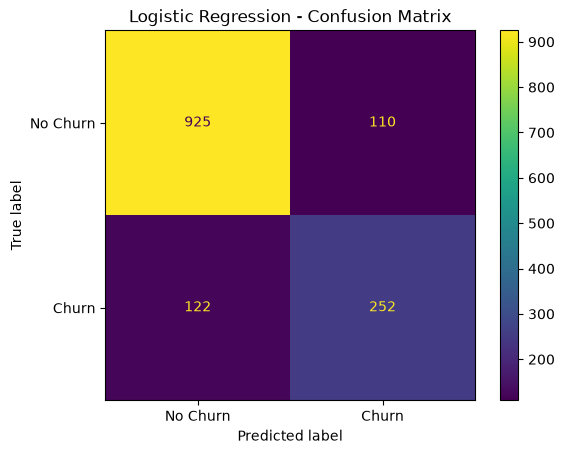

In [207]:
# Final Confusion Matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate predictions using our final Logistic Regression model
y_pred = LR_model.predict(xx_test)

# Create confusion matrix
cm = confusion_matrix(yy_test, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

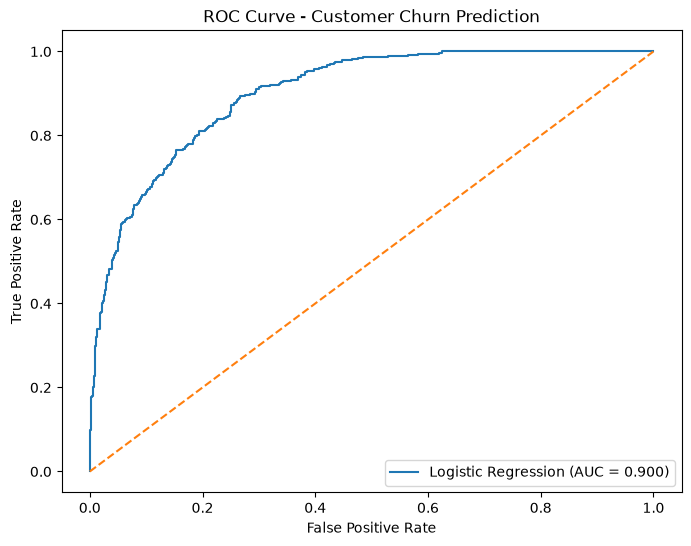

In [208]:
# Final ROC Curve

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get churn probabilities
y_prob = LR_model.predict_proba(xx_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(yy_test, y_prob)

# Calculate ROC-AUC
auc_score = roc_auc_score(yy_test, y_prob)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Customer Churn Prediction")
plt.legend()
plt.show()

In [209]:
# Save our feature-importance table
coef.to_csv("logistic_regression_coefficients.csv", index=False)

# This gives us a useful project artifact.


In [210]:
# Save the final model metrics

# Final model performance

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

final_metrics = {
    "Accuracy": accuracy_score(yy_test, y_pred),
    "Precision": precision_score(yy_test, y_pred),
    "Recall": recall_score(yy_test, y_pred),
    "F1-Score": f1_score(yy_test, y_pred),
    "ROC-AUC": roc_auc_score(yy_test, y_prob)
}

final_metrics

{'Accuracy': 0.8353442157558553,
 'Precision': 0.6961325966850829,
 'Recall': 0.6737967914438503,
 'F1-Score': 0.6847826086956522,
 'ROC-AUC': 0.9001653362267173}

In [211]:
# Compare all trained models

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        0.8353,
        0.7800,
        0.8332
    ],
    "ROC-AUC": [
        0.9002,
        0.7341,
        0.8894
    ],
    "Churn Recall": [
        0.6738,
        0.64,
        0.61
    ],
    "Churn F1": [
        0.6855,
        0.61,
        0.66
    ]
})

model_comparison

,Model,Accuracy,ROC-AUC,Churn Recall,Churn F1
0,Logistic Regression,0.8353,0.9002,0.6738,0.6855
1,Decision Tree,0.7800,0.7341,0.6400,0.6100
2,Random Forest,0.8332,0.8894,0.6100,0.6600


## Business Insights

Based on our exploratory analysis and Logistic Regression model, we identified several factors associated with customer churn:

### 1. Higher Monthly Charges Are Associated with Churn
Monthly Charge has the strongest positive coefficient in our Logistic Regression model. This indicates that customers with higher monthly charges have a higher likelihood of churn.

**Business Action:**  
The company should review pricing for high-paying customers and consider personalized discounts, bundled services, or value-based plans to improve perceived value.

### 2. Longer Tenure Is Associated with Customer Retention
Tenure in Months has a strong negative coefficient, indicating that customers who have stayed longer with the company are less likely to churn.

**Business Action:**  
The company should focus on retaining newer customers through onboarding programs, early engagement, loyalty benefits, and proactive support during the first months of their subscription.

### 3. Long-Term Contracts Help Reduce Churn
Both One-Year and Two-Year contracts have negative coefficients, with the Two-Year contract showing a particularly strong negative association with churn.

**Business Action:**  
The company can encourage customers to move from month-to-month plans to longer-term contracts by offering suitable incentives, discounts, or additional benefits.

### 4. Customer Referrals Are Associated with Lower Churn
Number of Referrals has one of the strongest negative coefficients in our model. Customers who generate more referrals tend to show lower churn likelihood.

**Business Action:**  
The company should strengthen referral and loyalty programs to increase customer engagement and encourage long-term relationships.

### 5. Dependents Are Associated with Lower Churn
Customers with dependents show a negative association with churn.

**Business Action:**  
Family-oriented plans, shared services, and benefits designed for households could help strengthen customer retention.

### 6. Security and Technical Support Services May Support Retention
Features such as Online Security and Premium Tech Support have negative coefficients, suggesting an association with lower churn.

**Business Action:**  
The company should consider promoting security and technical-support services as part of retention packages, particularly for customers who may need additional assistance.

### 7. High-Risk Customers Can Be Prioritized
Our model can help the company identify customers with a higher predicted probability of churn.

**Business Action:**  
Instead of applying the same retention strategy to every customer, the company can prioritize high-risk customers for personalized offers, proactive customer support, and targeted retention campaigns.

### Overall Business Recommendation

The company should focus particularly on **high-charge and newer customers who are not enrolled in long-term contracts**. Combining predictive churn scores with targeted retention strategies can help the company use its resources more efficiently and potentially reduce customer attrition.

## Final Conclusion

After comparing Logistic Regression, Decision Tree, and Random Forest, Logistic Regression was selected as our final model.

The model achieved an accuracy of approximately 83.5% and a ROC-AUC of 0.90 on the test dataset. It also achieved a churn recall of approximately 67%, meaning it successfully identified a substantial proportion of customers who were likely to churn.

The analysis suggests that factors such as monthly charges, tenure, contract duration, and customer referrals have an important relationship with churn.

Potential data leakage variables were removed before model training to ensure a more realistic evaluation.

The model can help telecom companies identify customers at higher risk of churn and support targeted customer-retention strategies.

## Project Limitations

- The model is based on historical customer data, so its predictions may not represent future customer behavior perfectly.
- Model performance depends on the quality and relevance of the available customer information.
- The identified relationships represent statistical associations and should not be interpreted as direct causal relationships.
- Some potentially informative variables were removed because they could introduce data leakage or would not be realistically available before churn prediction.
- The current model uses a standard classification threshold and could be further optimized based on the business cost of false positives and false negatives.